<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/09_priority_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 09 Logistic Regression Classifier (Priority Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds a Logistic Regression classifier to predict request priority (HIGH/MEDIUM/LOW), compared against the Naive Bayes baseline from Notebook 08.

## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the processed data

In [3]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_prio_train = np.load(f'{processed_dir}/y_prio_train.npy', allow_pickle=True)
y_prio_test = np.load(f'{processed_dir}/y_prio_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Building a pipeline combining vectorisation and classification

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

priority_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1500)),
    ('classifier', LogisticRegression(random_state=0, max_iter=1000))
])

priority_pipeline.fit(X_train, y_prio_train)

Pipeline(steps=[('vectorizer', CountVectorizer(max_features=1500)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=0))])

## Predicting the Test set results

In [5]:
y_pred = priority_pipeline.predict(X_test)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Predicted': y_pred[:15], 'Actual': y_prio_test[:15]})
print(comparison)

Sample predictions vs actual:
   Predicted  Actual
0     MEDIUM  MEDIUM
1       HIGH    HIGH
2     MEDIUM  MEDIUM
3       HIGH    HIGH
4        LOW     LOW
5       HIGH    HIGH
6        LOW     LOW
7     MEDIUM  MEDIUM
8       HIGH    HIGH
9     MEDIUM  MEDIUM
10    MEDIUM  MEDIUM
11       LOW     LOW
12    MEDIUM    HIGH
13       LOW  MEDIUM
14    MEDIUM    HIGH


## Making the Confusion Matrix

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_prio_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_prio_test, y_pred))

Confusion Matrix:
[[ 4396  2859  5762]
 [ 1019 19282  3748]
 [ 1528  2527  9755]]

Accuracy: 0.657146788269518


## Classification Report

In [7]:
print(classification_report(y_prio_test, y_pred))

              precision    recall  f1-score   support

        HIGH       0.63      0.34      0.44     13017
         LOW       0.78      0.80      0.79     24049
      MEDIUM       0.51      0.71      0.59     13810

    accuracy                           0.66     50876
   macro avg       0.64      0.62      0.61     50876
weighted avg       0.67      0.66      0.65     50876



## Visualising the Confusion Matrix

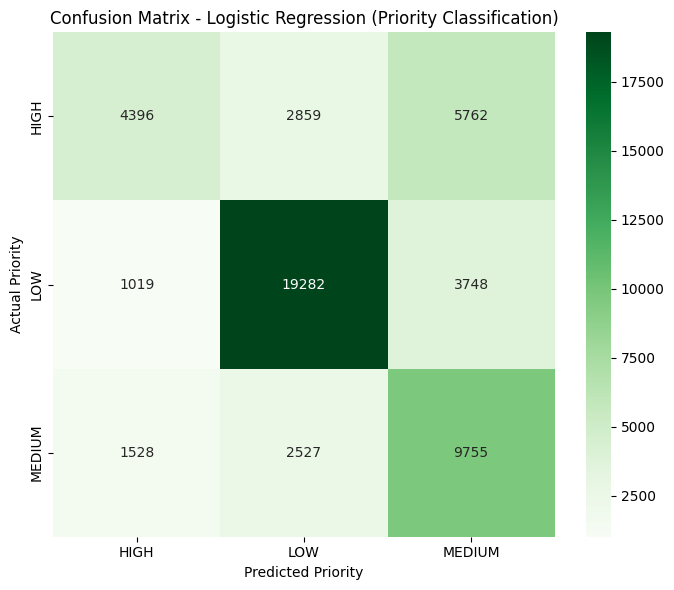

In [8]:
plt.figure(figsize=(7, 6))
unique_labels = sorted(set(y_prio_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Logistic Regression (Priority Classification)')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## Appending results to the priority comparison file

In [10]:
from sklearn.metrics import f1_score

results_path = '/content/drive/MyDrive/council-classifier/processed/priority_model_results.csv'
results_df = pd.read_csv(results_path)

new_result = {
    'model': 'Logistic Regression',
    'accuracy': accuracy_score(y_prio_test, y_pred),
    'f1_macro': f1_score(y_prio_test, y_pred, average='macro'),
    'f1_weighted': f1_score(y_prio_test, y_pred, average='weighted')
}

results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
results_df.to_csv(results_path, index=False)

print(results_df)

                 model  accuracy  f1_macro  f1_weighted
0          Naive Bayes  0.627801  0.587242     0.625258
1  Logistic Regression  0.657147  0.607315     0.647002
